## Pré-processamento

### Remover DC e tendências lentas

#### Zero-mean
Remove componente DC que distorce a energia espectral em f=0.

#### (Opcional) Detrend linear
Quando houver deriva lenta (temperatura, creep). Útil em sinais longos.

### Tratar *outliers* (opcional, mas prático)
Espículas raras (picos de impacto, saturação do sensor) podem “dominar” a escala.
*Clipping* robusto via MAD (median absolute deviation) ou z-score:

* Corte amplitudes acima de k desvios (ex.: k=6 MADs).

* Mantém o conteúdo útil e evita explodir a normalização.

### Suavizar bordas (*taper*)
Por quê? Bordas “duras” geram *leakage* na FFT.

Como? Se você vai usar Welch com janela Hann, não é obrigatório aplicar outra janela global.

Se você está cortando um trecho do sinal, aplicar um taper leve (ex.: Tukey α=0.1) no trecho inteiro ajuda a suavizar apenas as bordas sem “re-janelar” demais.

Regra prática: Welch já usa Hann por segmento → use Tukey leve no trecho global só se houver cortes, senão pode pular.

### Normalização de energia (RMS)
Por quê? Equaliza a escala entre amostras (cargas/níveis diferentes) e facilita o treinamento.

Como? $x ← x / (rms(x) + ε)$ com $ε≈1e−12$.

* Faça por amostra (não por lote) e repita no teste.

### Passa-faixa / passa-alta (opcional, mas muito útil)

Por quê? Em rolamentos, as **ressonâncias** amplificam bandas onde moram as bandas laterais (BPFI/BPFO/BSF). Focar nelas aumenta SNR.

Como? Filtro **Butterworth** 4ª–6ª ordem com $f1–f2$ em kHz típicas do banco:

Exemplo CWRU (DE, 48 kHz): **1.8–3.7 kHz** é um recorte comum para realçar conteúdo de falha (ajuste à sua montagem).

Se não souber a banda, um **passa-alta** em ~500–800 Hz já remove muita baixa-frequência mecânica.

Aplique **filtfilt** (zero-fase) para não distorcer fase.

In [2]:
import numpy as np
from scipy.signal import butter, filtfilt, detrend, windows

def design_butter_band(fs, f1=None, f2=None, order=4, btype='band'):
    nyq = 0.5 * fs
    if btype == 'band':
        assert f1 is not None and f2 is not None and f2 > f1
        Wn = [f1/nyq, f2/nyq]
    elif btype == 'high':
        assert f1 is not None
        Wn = f1/nyq
    elif btype == 'low':
        assert f2 is not None
        Wn = f2/nyq
    else:
        raise ValueError("btype must be 'band', 'high' or 'low'")
    return butter(order, Wn, btype=btype, output='sos')

def robust_clip(x, k_mad=6.0):
    # Clip using MAD around the median (robust to outliers)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    lo, hi = med - k_mad * 1.4826 * mad, med + k_mad * 1.4826 * mad
    return np.clip(x, lo, hi)

def preprocess_time_signal(
    x,
    fs,
    segment_len=None,       # e.g., 4096
    crop_mode='center',     # 'center' or 'random'
    apply_detrend=False,    # linear detrend if needed
    clip_outliers=True,     # robust clipping
    clip_k_mad=6.0,
    global_taper='tukey',   # None | 'tukey' | 'hann'
    tukey_alpha=0.1,
    bandpass=None,          # (f1, f2) in Hz, e.g., (1800, 3700)
    highpass=None,          # f1 in Hz if you prefer high-pass only
    filt_order=4,
    rms_norm=True,
    eps=1e-12,
    rng=None                # np.random.Generator for reproducible random crops
):
    # 0) to float32 and finite check
    x = np.asarray(x, dtype=np.float32)
    if not np.all(np.isfinite(x)) or x.size == 0:
        return np.zeros(segment_len if segment_len else 1, dtype=np.float32)

    # 1) (Optional) crop to fixed length
    if segment_len is not None and x.size >= segment_len:
        if crop_mode == 'center':
            start = (x.size - segment_len) // 2
        elif crop_mode == 'random':
            r = np.random.default_rng() if rng is None else rng
            start = int(r.integers(0, x.size - segment_len + 1))
        else:
            raise ValueError("crop_mode must be 'center' or 'random'")
        x = x[start:start+segment_len]

    # 2) Zero-mean (remove DC)
    x = x - np.mean(x, dtype=np.float32)

    # 3) (Optional) linear detrend
    if apply_detrend:
        x = detrend(x, type='linear')

    # 4) (Optional) robust clipping of outliers
    if clip_outliers:
        x = robust_clip(x, k_mad=clip_k_mad)

    # 5) (Optional) band selection (zero-phase to avoid phase distortion)
    if bandpass is not None:
        f1, f2 = bandpass
        sos = design_butter_band(fs, f1=f1, f2=f2, order=filt_order, btype='band')
        x = filtfilt(sos, [1.0], x, method='gust')  # scipy >=1.10 supports sos in filtfilt
    elif highpass is not None:
        sos = design_butter_band(fs, f1=highpass, order=filt_order, btype='high')
        x = filtfilt(sos, [1.0], x, method='gust')

    # 6) (Optional) global taper to soften boundaries if you cropped
    if global_taper is not None:
        N = x.size
        if global_taper == 'tukey':
            win = windows.tukey(N, alpha=tukey_alpha, sym=False).astype(np.float32)
        elif global_taper == 'hann':
            win = windows.hann(N, sym=False).astype(np.float32)
        else:
            raise ValueError("global_taper must be None, 'tukey', or 'hann'")
        x = x * win

    # 7) RMS normalization
    if rms_norm:
        rms = np.sqrt(np.mean(x**2, dtype=np.float32)) + eps
        x = x / rms

    # 8) Guard against near-zero variance
    if np.std(x) < 1e-12 or not np.all(np.isfinite(x)):
        x = np.zeros_like(x, dtype=np.float32)

    return x.astype(np.float32)


## PSD de Welch

Dominant peaks (Hz, value):
   2994.14 Hz  |  8.963
   2501.95 Hz  |  2.796
   2604.49 Hz  |  1.343
   3219.73 Hz  |  -0.448
   3322.27 Hz  |  -1.589


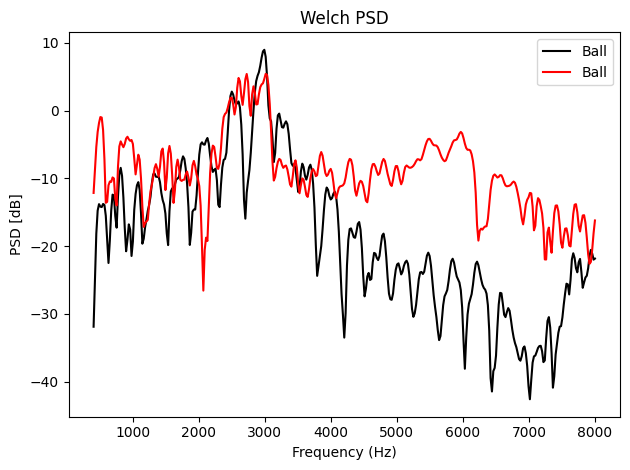

In [70]:
import numpy as np
from scipy.signal import welch, get_window, find_peaks

def psd_welch(
    x,
    fs,
    nperseg=1024,
    noverlap=512,
    nfft=2048,
    window="hann",
    detrend=False,
    scaling="density",     # "density" (V^2/Hz) or "spectrum" (V^2)
    average="mean",        # "mean" (Welch standard) or "median"
    log_scale=None,        # None | "log1p" | "db"
    db_eps=1e-12,
    fmax=None              # e.g., 8000.0 to keep up to 8 kHz
):
    """
    Compute Welch Power Spectral Density (PSD) of a 1D time series.

    Parameters
    ----------
    x : 1D np.ndarray
        Time-domain signal (float32 recommended).
    fs : float
        Sampling frequency in Hz.
    nperseg, noverlap, nfft : int
        Welch segmentation and FFT grid params.
    window : str or tuple or array_like
        Window for each segment. "hann" is a good default.
    detrend : bool or str
        If True or "linear", remove trend in each segment.
    scaling : {"density","spectrum"}
        "density" yields V^2/Hz (PSD), "spectrum" yields V^2 (power).
    average : {"mean","median"}
        Averaging across periodograms. "median" can be more robust to outliers.
    log_scale : None | "log1p" | "db"
        Optional non-linear compression of PSD.
        - "log1p": np.log1p(Pxx)  (safe for zeros)
        - "db": 10*log10(Pxx + db_eps)
    db_eps : float
        Small offset to avoid log(0) if log_scale="db".
    fmax : float or None
        If provided, keep only frequencies <= fmax.

    Returns
    -------
    f : np.ndarray, shape (F,)
        Frequency axis (Hz), one-sided for real x.
    Pxx : np.ndarray, shape (F,)
        PSD values, possibly transformed by log_scale.
    """
    # Ensure float32 and finite
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 1 or x.size == 0 or not np.all(np.isfinite(x)):
        raise ValueError("Input x must be a finite 1D array.")

    # Welch PSD
    f, Pxx = welch(
        x,
        fs=fs,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        detrend=detrend,
        return_onesided=True,
        scaling=scaling,
        average=average
    )
    Pxx = Pxx.astype(np.float32)

    # Optional band limit (0..fmax)
    if fmax is not None:
        mask = f <= float(fmax)
        f, Pxx = f[mask], Pxx[mask]

    # Optional non-linear compression
    if log_scale is None:
        pass
    elif log_scale.lower() == "log1p":
        Pxx = np.log1p(Pxx)
    elif log_scale.lower() == "db":
        Pxx = 10.0 * np.log10(Pxx + db_eps)
    else:
        raise ValueError("log_scale must be None, 'log1p', or 'db'.")

    return f, Pxx


# --------- Example usage (run this file directly) ----------
if __name__ == "__main__":
    # Synthetic example: two tones + noise
    fs = 42_000
    dur = 0.5  # seconds
    t = np.arange(int(fs*dur)) / fs
    
    x_b = [
        np.load("data/processed/uored/setup_1/train/B_11_1_0.npy"),
        np.load("data/processed/uored/setup_1/train/B_12_1_105.npy"),
        np.load("data/processed/uored/setup_1/train/B_13_1_144.npy")]
    x_i = [
        np.load("data/processed/uored/setup_1/train/I_1_1_65.npy"),
        np.load("data/processed/uored/setup_1/train/I_2_1_198.npy"),
        np.load("data/processed/uored/setup_1/train/I_3_1_0.npy")]
    x_o = [
        np.load("data/processed/uored/setup_1/train/O_6_1_58.npy"),
        np.load("data/processed/uored/setup_1/train/O_7_1_64.npy"),
        np.load("data/processed/uored/setup_1/train/O_8_1_111.npy")]
    
    x_pp = preprocess_time_signal(x_b[0], 
        fs=42_000,
        segment_len=None,       # e.g., 4096
        crop_mode='center',     # 'center' or 'random'
        apply_detrend=True,    # linear detrend if needed
        clip_outliers=True,     # robust clipping
        clip_k_mad=6.0,
        global_taper='tukey',   # None | 'tukey' | 'hann'
        tukey_alpha=0.1,
        bandpass=None,          # (f1, f2) in Hz, e.g., (1800, 3700)
        highpass=None,          # f1 in Hz if you prefer high-pass only
        filt_order=4,
        rms_norm=False,
        eps=1e-12,
        rng=None                # np.random.Generator for reproducible random crops
    )



    # =========== Ball =====================
    # Compute PSD with Welch
    f, P = psd_welch(
        x_b[0], fs,
        nperseg=1024,
        noverlap=512,
        nfft=2048,
        window="hann",
        scaling="density",
        average="mean",
        log_scale="db",     # try None | "log1p" | "db"
        fmax=8000.0
    )

    f2, P2 = psd_welch(
        x_b[2], fs,
        nperseg=1024,
        noverlap=512,
        nfft=2048,
        window="hann",
        scaling="density",
        average="mean",
        log_scale="db",     # try None | "log1p" | "db"
        fmax=8000.0
    )

    f3, P3 = psd_welch(
        x_b[1], fs,
        nperseg=1024,
        noverlap=512,
        nfft=2048,
        window="hann",
        scaling="density",
        average="mean",
        log_scale="db",     # try None | "log1p" | "db"
        fmax=8000.0
    )


    f_pp, P_pp = psd_welch(
        x_pp, fs,
        nperseg=1024,
        noverlap=512,
        nfft=2048,
        window="hann",
        scaling="density",
        average="mean",
        log_scale="log1p",     # try None | "log1p" | "db"
        fmax=8000.0
    )
    # P_pp += 10



    # =========== Inner =====================
    # Compute PSD with Welch
    f_o, P_o = psd_welch(
        x_i[0], fs,
        nperseg=1024,
        noverlap=512,
        nfft=2048,
        window="hann",
        scaling="density",
        average="mean",
        log_scale="db",     # try None | "log1p" | "db"
        fmax=8000.0
    )

    f_o2, P_o2 = psd_welch(
        x_i[1], fs,
        nperseg=1024,
        noverlap=512,
        nfft=2048,
        window="hann",
        scaling="density",
        average="mean",
        log_scale="db",     # try None | "log1p" | "db"
        fmax=8000.0
    )

    f_o3, P_o3 = psd_welch(
        x_i[2], fs,
        nperseg=1024,
        noverlap=512,
        nfft=2048,
        window="hann",
        scaling="density",
        average="mean",
        log_scale="db",     # try None | "log1p" | "db"
        fmax=8000.0
    )




    # Peek the dominant peaks around expected frequencies
    # (works on dB or linear the same way)
    peaks, _ = find_peaks(P, distance=5)
    topk = 5 if peaks.size >= 5 else peaks.size
    idx_sorted = np.argsort(P[peaks])[-topk:]
    dom_freqs = f[peaks][idx_sorted]
    dom_vals  = P[peaks][idx_sorted]

    print("Dominant peaks (Hz, value):")
    for fr, val in zip(dom_freqs[::-1], dom_vals[::-1]):
        print(f"  {fr:8.2f} Hz  |  {val:.3f}")

    # NOTE: If you want to plot:
    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(f[20:], P[20:], color='k')
    # plt.plot(f2[20:], P2[20:], color='orange')
    # plt.plot(f3[20:], P3[20:], color='green')
    # plt.plot(f_pp[20:], P_pp[20:], color='blue')

    # plt.plot(f_o[20:], P_o[20:], color='pink')
    plt.plot(f_o2[20:], P_o2[20:], color='red')
    # plt.plot(f_o3[20:], P_o3[20:], color='red')

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD [dB]" if isinstance("db", str) else "Power")
    plt.title("Welch PSD")
    plt.legend(['Ball', 'Ball', 'Ball', 'Outer Race', 'Outer Race', 'Outer Race'])
    plt.tight_layout()
    plt.show()


In [2]:
# freq_psd_dataset.py
import os
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.signal import welch, windows, butter, sosfiltfilt

# ---------------------- Helpers: time preprocessing ---------------------- #
def robust_clip(x, k_mad=6.0):
    """Robust amplitude clipping using MAD to limit outliers."""
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    lo, hi = med - k_mad * 1.4826 * mad, med + k_mad * 1.4826 * mad
    return np.clip(x, lo, hi).astype(np.float32)

def butter_sos(fs, f1=None, f2=None, order=4, btype="band"):
    """Design Butterworth filter in SOS form normalized by Nyquist."""
    nyq = 0.5 * fs
    if btype == "band":
        if f1 is None or f2 is None or not (0 < f1 < f2 < nyq):
            raise ValueError("Invalid band (f1,f2) for band-pass.")
        Wn = [f1/nyq, f2/nyq]
    elif btype == "high":
        if f1 is None or not (0 < f1 < nyq):
            raise ValueError("Invalid f1 for high-pass.")
        Wn = f1/nyq
    elif btype == "low":
        if f2 is None or not (0 < f2 < nyq):
            raise ValueError("Invalid f2 for low-pass.")
        Wn = f2/nyq
    else:
        raise ValueError("btype must be 'band'|'high'|'low'")
    from scipy.signal import butter
    return butter(order, Wn, btype=btype, output="sos")

def preprocess_time_signal(
    x,
    fs,
    segment_len=None,        # e.g., 4096 (crop center); None keeps full length
    clip_outliers=True,
    clip_k_mad=6.0,
    apply_band=None,         # tuple like (f1,f2) in Hz for band-pass; or None
    taper_tukey_alpha=0.1,   # use a light Tukey only if we cropped
    rms_norm=True,
    eps=1e-12
):
    """Minimal, stable preprocessing for bearing signals before PSD."""
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 1 or x.size == 0 or not np.all(np.isfinite(x)):
        raise ValueError("Input must be a finite 1D array.")

    # (1) Optional center crop to fixed length
    if segment_len is not None and x.size >= segment_len:
        start = (x.size - segment_len) // 2
        x = x[start:start+segment_len]

    # (2) Zero-mean
    x = x - np.mean(x, dtype=np.float32)

    # (3) Robust clipping to limit rare spikes
    if clip_outliers:
        x = robust_clip(x, k_mad=clip_k_mad)

    # (4) Optional band selection (zero-phase)
    if apply_band is not None:
        f1, f2 = apply_band
        sos = butter_sos(fs, f1=f1, f2=f2, order=4, btype="band")
        x = sosfiltfilt(sos, x).astype(np.float32)

    # (5) Light taper only if we cropped (to soften edges)
    if segment_len is not None:
        win = windows.tukey(x.size, alpha=taper_tukey_alpha, sym=False).astype(np.float32)
        x = x * win

    # (6) RMS normalization
    if rms_norm:
        rms = np.sqrt(np.mean(x**2, dtype=np.float32)) + eps
        x = x / rms

    return x.astype(np.float32)

# ---------------------- Helper: Welch PSD ---------------------- #
def compute_psd_welch(
    x,
    fs,
    nperseg=1024,
    noverlap=512,
    nfft=2048,
    window="hann",
    scaling="density",
    average="mean",
    log_scale="log1p",   # "log1p" | "db" | None
    db_eps=1e-12,
    fmax=None
):
    """Return (f, Pxx) where Pxx is PSD possibly in log scale, one-sided."""
    f, Pxx = welch(
        x,
        fs=fs,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        detrend=False,
        return_onesided=True,
        scaling=scaling,
        average=average
    )
    Pxx = Pxx.astype(np.float32)

    if fmax is not None:
        m = f <= float(fmax)
        f, Pxx = f[m], Pxx[m]

    if log_scale is None:
        pass
    elif log_scale.lower() == "log1p":
        Pxx = np.log1p(Pxx)
    elif log_scale.lower() == "db":
        Pxx = 10.0 * np.log10(Pxx + db_eps)
    else:
        raise ValueError("log_scale must be None|'log1p'|'db'.")

    return f.astype(np.float32), Pxx.astype(np.float32)

# ---------------------- Dataset ---------------------- #
class BearingPSDDataset(Dataset):
    """
    Reads .npy files from a flat folder (e.g., root/train) where filenames start with
    the class letter: B_*.npy, I_*.npy, N_*.npy, O_*.npy.

    Returns tensors:
        x: (1, F) PSD (channel-first for 1D CNN along frequency)
        y: scalar class index in {0..3}
    """
    LABELS = ["B", "I", "N", "O"]  # fixed order

    def __init__(
        self,
        folder,
        fs,
        segment_len=None,
        apply_band=None,          # e.g., (1800.0, 3700.0) or None
        welch_nperseg=1024,
        welch_noverlap=512,
        welch_nfft=2048,
        welch_window="hann",
        welch_scaling="density",
        welch_average="mean",
        welch_log="log1p",
        welch_fmax=None
    ):
        super().__init__()
        folder = Path(folder)
        if not folder.is_dir():
            raise FileNotFoundError(f"Folder not found: {folder}")

        # Collect all .npy files whose first char maps to a known label
        self.items = []
        self.label_to_idx = {lbl: i for i, lbl in enumerate(self.LABELS)}
        for p in sorted(folder.glob("*.npy")):
            stem = p.name
            if len(stem) < 1:
                continue
            prefix = stem[0].upper()
            if prefix in self.label_to_idx:
                self.items.append((str(p), self.label_to_idx[prefix]))
        if len(self.items) == 0:
            raise RuntimeError(f"No .npy files with labels {self.LABELS} found in {folder}")

        # Store params
        self.fs = float(fs)
        self.segment_len = segment_len
        self.apply_band = apply_band

        self.welch_nperseg = welch_nperseg
        self.welch_noverlap = welch_noverlap
        self.welch_nfft = welch_nfft
        self.welch_window = welch_window
        self.welch_scaling = welch_scaling
        self.welch_average = welch_average
        self.welch_log = welch_log
        self.welch_fmax = welch_fmax

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y = self.items[idx]
        # Load 1D time signal
        x = np.load(path)  # shape (N,)

        # Time-domain preprocessing
        x = preprocess_time_signal(
            x,
            fs=self.fs,
            segment_len=self.segment_len,
            clip_outliers=True,
            clip_k_mad=6.0,
            apply_band=self.apply_band,   # e.g., (1800, 3700) for CWRU DE 48kHz
            taper_tukey_alpha=0.1,
            rms_norm=True
        )

        # Welch PSD → (F,)
        f, psd = compute_psd_welch(
            x,
            fs=self.fs,
            nperseg=self.welch_nperseg,
            noverlap=self.welch_noverlap,
            nfft=self.welch_nfft,
            window=self.welch_window,
            scaling=self.welch_scaling,
            average=self.welch_average,
            log_scale=self.welch_log,
            fmax=self.welch_fmax
        )

        # To torch tensor with channel-first shape (1, F)
        psd_t = torch.from_numpy(psd).unsqueeze(0)  # (1, F)
        y_t = torch.tensor(y, dtype=torch.long)
        return psd_t, y_t



In [4]:
import numpy as np

def superpose_signals_freq(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    """
    Superpose two time-domain signals in the frequency domain
    and return the combined signal in the time domain.
    
    Args:
        x1 (np.ndarray): First time-domain signal
        x2 (np.ndarray): Second time-domain signal
    
    Returns:
        np.ndarray: Combined time-domain signal after frequency-domain superposition
    """
    # Ensure signals have the same length
    min_len = min(len(x1), len(x2))
    x1 = x1[:min_len]
    x2 = x2[:min_len]
    
    # FFT of both signals
    X1 = np.fft.fft(x1)
    X2 = np.fft.fft(x2)
    
    # Superpose in frequency domain (amplitude addition)
    X_combined = X1 + X2
    
    # Inverse FFT to get back to time domain
    x_combined = np.fft.ifft(X_combined)
    
    # Return real part (small imaginary parts come from numerical errors)
    return np.real(x_combined)


(2048,) (2048,) (2048,)


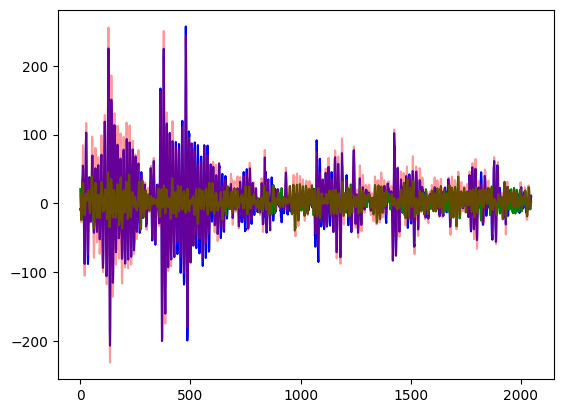

In [15]:
x = np.load("data/processed/uored/setup_1/train/B_11_1_0.npy")
y = np.load("data/processed/uored/setup_1/train/B_12_1_0.npy")

z = superpose_signals_freq(x, y)

print(x.shape, y.shape, z.shape)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(x, color="blue")
plt.plot(y, color="green")
plt.plot(z, color="red", alpha=0.4)
plt.show()

In [17]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def predict_soft_voting(
    model,
    long_signal: np.ndarray,
    seg_len: int = 250,
    n_segments: int = 8,
    transform=None,   # same per-segment preprocessing you used in training
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    class_names=None  # e.g., ["B", "I", "N", "O"]
):
    """
    Predict a long signal by splitting it into segments and averaging per-segment softmax probabilities.
    
    Args:
        model: PyTorch model. Expects input shaped like (N, C, L) or (N, L) depending on your model.
        long_signal: 1D numpy array with length = seg_len * n_segments (e.g., 2500).
        seg_len: Segment length used in training (e.g., 250).
        n_segments: Number of segments to split the long signal (e.g., 10).
        transform: Optional callable applied per segment (must mimic training preprocessing).
        device: "cuda" or "cpu".
        class_names: Optional list of class names for readability.
    
    Returns:
        pred_idx: int, final predicted class index.
        pred_name: str or None, final predicted class name if class_names provided.
        seg_probs: (n_segments, n_classes) numpy array with per-segment probabilities.
        mean_probs: (n_classes,) numpy array with averaged probabilities across segments.
    """
    model.eval().to(device)

    total_len = len(long_signal)
    expected_len = seg_len * n_segments
    if total_len != expected_len:
        raise ValueError(
            f"Expected signal length {expected_len} (= {seg_len} * {n_segments}), "
            f"but got {total_len}."
        )

    # Build segments (contiguous, no overlap)
    segments = []
    for i in range(n_segments):
        start = i * seg_len
        end = start + seg_len
        x = long_signal[start:end].astype(np.float32, copy=False)

        # Apply the same per-window preprocessing used during training (e.g., z-score, RMS norm)
        if transform is not None:
            x = transform(x)  # should return np.ndarray shaped (seg_len,) or (1, seg_len)

        # Ensure shape (C, L) if your model expects channels-first 1D input.
        # Adjust this block to match your model's forward signature.
        if x.ndim == 1:
            x = x[None, :]  # (1, L) -> one channel
        segments.append(x)

    batch = np.stack(segments, axis=0)  # (N, C, L)
    batch_t = torch.from_numpy(batch).to(device)

    # Forward pass
    logits = model(batch_t)                    # (N, n_classes)
    probs = F.softmax(logits, dim=-1)         # (N, n_classes)
    seg_probs = probs.detach().cpu().numpy()  # numpy for aggregation/logging

    # Soft voting: mean of probabilities across segments
    mean_probs = seg_probs.mean(axis=0)       # (n_classes,)
    pred_idx = int(mean_probs.argmax())
    pred_name = class_names[pred_idx] if class_names is not None else None

    return pred_idx, pred_name, seg_probs, mean_probs


# =======================
# Example usage
# =======================
if __name__ == "__main__":
    # Dummy example (replace with your real model and signal)
    class DummyNet(torch.nn.Module):
        def __init__(self, n_classes=4):
            super().__init__()
            self.fc = torch.nn.Linear(250, n_classes)
        def forward(self, x):
            # x: (N, 1, 250) -> flatten last two dims if needed
            if x.ndim == 3:
                x = x.squeeze(1)  # (N, 250)
            return self.fc(x)

    # Suppose you trained with windows of length 250
    model = DummyNet(n_classes=4)

    # Fake 2500-point test signal (replace with your real signal)
    signal_2500 = np.random.randn(2500).astype(np.float32)

    # Optional: training-like transform per segment
    def my_train_transform(seg: np.ndarray) -> np.ndarray:
        # Example: simple z-score per segment (match your training preprocessing!)
        s = seg.astype(np.float32)
        std = s.std() if s.std() > 1e-8 else 1.0
        s = (s - s.mean()) / std
        return s  # shape (250,)

    pred_idx, pred_name, seg_probs, mean_probs = predict_soft_voting(
        model=model,
        long_signal=x[:2000],
        seg_len=250,
        n_segments=8,
        transform=my_train_transform,
        class_names=["B", "I", "N", "O"]
    )

    print("Final class index:", pred_idx)
    print("Final class name :", pred_name)
    print("Mean probabilities:", mean_probs)


Final class index: 3
Final class name : O
Mean probabilities: [0.22932251 0.22179988 0.2528156  0.296062  ]


In [ ]:
# train_freq_cnn.py
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from src.models import BearingCNN1D, MCNN_LSTM
import librosa

# Import the dataset you created earlier
# Make sure freq_psd_dataset.py (from the previous message) is accessible in PYTHONPATH
# from freq_psd_dataset import BearingPSDDataset



# --------------------------- Dataset --------------------------- #

class BearingDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        """
        Args:
            root_dir (str): Path to the dataset root directory (contains 'train' and 'test').
            split (str): One of 'train' or 'test'.
            transform (callable, optional): Optional transform applied to each sample.
        """
        self.root_dir = os.path.join(root_dir, split)
        self.transform = transform

        # Class mapping
        self.class_map = {"B": 0, "I": 1, "N": 2, "O": 3}

        # Get all .npy files
        self.samples = []
        for fname in os.listdir(self.root_dir):
            if fname.endswith(".npy"):
                label_char = fname[0]  # first character gives class
                if label_char in self.class_map:
                    label = self.class_map[label_char]
                    path = os.path.join(self.root_dir, fname)
                    self.samples.append((path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        data = np.load(path)[:2000].astype(np.float32)
        data = torch.from_numpy(data)

        if self.transform:
            data = self.transform(data)

        return data, label


# Downsampling
def resample(signal, fs_orig=42000, fs_target=6000):
    if isinstance(signal, torch.Tensor):
        signal = signal.detach().cpu().numpy()
    signal = np.asarray(signal).squeeze().astype(np.float32)
    y_ds = librosa.resample(y=signal, orig_sr=fs_orig, target_sr=fs_target, res_type="polyphase")
    x = torch.from_numpy(y_ds).float()          # (250,)
    x = x.unsqueeze(0).contiguous()             # (1, 250)  <- adiciona canal
    return x



# --------------------------- Model (1D CNN) --------------------------- #
class SEBlock(nn.Module):
    """Squeeze-and-Excitation for channel-wise attention over frequency maps."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, channels // reduction, 1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv1d(channels // reduction, channels, 1, bias=True),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.avg(x)
        w = self.fc(w)
        return x * w

class FreqCNN1D(nn.Module):
    """
    Input: (B, 1, F) where F is the number of frequency bins from the PSD.
    Convs operate along the frequency axis (dim=2).
    """
    def __init__(self, num_classes, in_ch=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16), nn.ReLU(),
            SEBlock(16),
            nn.MaxPool1d(4),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            SEBlock(32),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
            SEBlock(64),

            nn.AdaptiveAvgPool1d(1)  # -> (B, 64, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),          # -> (B, 64)
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# ------------------------- Train / Eval loops ------------------------- #
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    ce = nn.CrossEntropyLoss()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = ce(logits, yb)
        loss.backward()
        optimizer.step()

        loss_sum += float(loss) * yb.size(0)
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    ce = nn.CrossEntropyLoss()
    total, correct, loss_sum = 0, 0, 0.0
    all_preds, all_targets = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = ce(logits, yb)

        loss_sum += float(loss) * yb.size(0)
        pred = logits.argmax(1)

        correct += (pred == yb).sum().item()
        total += yb.size(0)

        all_preds.append(pred.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    acc = correct / total
    return loss_sum / total, acc, y_true, y_pred

# ------------------------------- Main -------------------------------- #
def main(config):
    device = config["device"]
    os.makedirs(Path(config["ckpt_path"]).parent, exist_ok=True)

    # Datasets / loaders
    train_ds = BearingDataset(config["root"], split="train", transform=resample)
    # BearingPSDDataset(
    #     folder=Path(config["root"]) / "train",
    #     fs=config["fs"],
    #     segment_len=config["segment_len"],
    #     apply_band=config["apply_band"],
    #     welch_nperseg=config["welch_nperseg"],
    #     welch_noverlap=config["welch_noverlap"],
    #     welch_nfft=config["welch_nfft"],
    #     welch_window=config["welch_window"],
    #     welch_scaling=config["welch_scaling"],
    #     welch_average=config["welch_average"],
    #     welch_log=config["welch_log"],
    #     welch_fmax=config["welch_fmax"]
    # )
    test_ds = BearingDataset(config["root"], split="test", transform=resample)
    # BearingPSDDataset(
    #     folder=Path(config["root"]) / "test",
    #     fs=config["fs"],
    #     segment_len=config["segment_len"],
    #     apply_band=config["apply_band"],
    #     welch_nperseg=config["welch_nperseg"],
    #     welch_noverlap=config["welch_noverlap"],
    #     welch_nfft=config["welch_nfft"],
    #     welch_window=config["welch_window"],
    #     welch_scaling=config["welch_scaling"],
    #     welch_average=config["welch_average"],
    #     welch_log=config["welch_log"],
    #     welch_fmax=config["welch_fmax"]
    # )

    num_classes = len(BearingPSDDataset.LABELS)
    class_names = BearingPSDDataset.LABELS

    train_ld = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True,
                          num_workers=config["num_workers"], pin_memory=True)
    test_ld  = DataLoader(test_ds,  batch_size=config["batch_size"], shuffle=False,
                          num_workers=config["num_workers"], pin_memory=True)

    # Build model
    model = MCNN_LSTM(num_classes=num_classes).to(device)

    # Optimizer (only trainable params)
    optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad),
                                 lr=config["lr"])

    best_acc = 0.0
    for epoch in range(1, config["epochs"] + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_ld, optimizer, device)
        te_loss, te_acc, y_true, y_pred = eval_epoch(model, test_ld, device)
        print(f"Epoch {epoch:03d} | "
              f"train: loss={tr_loss:.4f}, acc={tr_acc:.3f} | "
              f"test: loss={te_loss:.4f}, acc={te_acc:.3f}")

        # Save best by test accuracy
        if te_acc > best_acc:
            best_acc = te_acc
            torch.save({"model": model.state_dict(),
                        "class_names": class_names}, config["ckpt_path"])

    # Final evaluation on test set (confusion matrix & F1)
    _, _, y_true, y_pred = eval_epoch(model, test_ld, device)

    print("\n================= FINAL METRICS (TEST) =================")
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_micro = f1_score(y_true, y_pred, average="micro")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-macro: {f1_macro:.4f}")
    print(f"F1-micro: {f1_micro:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix (rows = true, cols = pred):")
    print(cm)

    print("\nClassification Report:")
    # Show per-class precision/recall/F1 with class names B/I/N/O
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    print(f"\nBest test accuracy during training: {best_acc:.4f}")
    print(f"Saved best checkpoint to: {config['ckpt_path']}")

    return acc

if __name__ == "__main__":

    # ----------------------------- Config ----------------------------- #
    def config(n):
        return {
        "root": f"data/processed/uored/setup_{n}",          # folder that contains train/ and test/
        "fs": 6000,             # sampling freq (adjust to your data, e.g., 42000)
        "segment_len": 4096,     # center crop length; set None to keep full
        "apply_band": None,  # None or (f1,f2) in Hz; tune per setup
        "welch_nperseg": 1024,
        "welch_noverlap": 512,
        "welch_nfft": 2048,
        "welch_window": "hann",
        "welch_scaling": "density",
        "welch_average": "mean",
        "welch_log": "db",    # try "db" as well
        "welch_fmax": 8000.0,    # trims PSD to 0..fmax Hz to reduce F
        "batch_size": 64,
        "epochs": 12,
        "lr": 1e-4,
        "num_workers": 2,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "ckpt_path": "checkpoints/freq_cnn_best.pt"
    }

    total_acc = []
    for n in range(1,11):
        print(f'--------------\nSetup {n}\n------------------')
        acc = main(config(n))
        total_acc.append(acc)
    
    print("-"*10)
    print(f"Total Accuracy: {np.mean(total_acc):.4f}")


--------------
Setup 1
------------------


Epoch 001 | train: loss=1.3607, acc=0.329 | test: loss=1.3257, acc=0.500
Epoch 002 | train: loss=1.2418, acc=0.642 | test: loss=1.1732, acc=0.607
Epoch 003 | train: loss=0.9975, acc=0.757 | test: loss=1.0506, acc=0.543
Epoch 004 | train: loss=0.7518, acc=0.810 | test: loss=1.0408, acc=0.557
Epoch 005 | train: loss=0.5800, acc=0.881 | test: loss=1.0205, acc=0.696
Epoch 006 | train: loss=0.4347, acc=0.937 | test: loss=1.1708, acc=0.585
Epoch 007 | train: loss=0.3175, acc=0.980 | test: loss=1.2577, acc=0.598
Epoch 008 | train: loss=0.2404, acc=0.992 | test: loss=1.3639, acc=0.581
Epoch 009 | train: loss=0.1914, acc=0.995 | test: loss=1.4298, acc=0.585
Epoch 010 | train: loss=0.1590, acc=0.995 | test: loss=1.4916, acc=0.585

================= FINAL METRICS (TEST) =================
Accuracy: 0.5845
F1-macro: 0.5430
F1-micro: 0.5845

Confusion Matrix (rows = true, cols = pred):
[[ 71   0 139   0]
 [  0 210   0   0]
 [  0   0   0 210]
 [  0   0   0 210]]

Classification Report:
              

In [19]:
def resample(signal, fs_orig=42000, fs_target=6000):
    if isinstance(signal, torch.Tensor):
        signal = signal.detach().cpu().numpy()
    signal = np.asarray(signal).squeeze().astype(np.float32)
    y_ds = librosa.resample(y=signal, orig_sr=fs_orig, target_sr=fs_target, res_type="polyphase")
    x = torch.from_numpy(y_ds).float()          # (250,)
    x = x.unsqueeze(0).contiguous()             # (1, 250)  <- adiciona canal
    return x

x = np.random.randn(17500).astype(np.float32)

x_resampled = resample(x)
x.shape, x_resampled.shape

((17500,), torch.Size([1, 2500]))

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_signal(x, y, fs=6000, title="Signal", xlabel=None, ylabel="Amplitude"):
    """
    Plot a 1D time series.

    Args:
        x (array-like): 1D signal to plot.
        fs (float, optional): Sampling rate in Hz. If provided, x-axis is time (s).
                              If None, x-axis is sample index.
        title (str): Plot title.
        xlabel (str, optional): X-axis label. If None, chosen automatically.
        ylabel (str): Y-axis label (default: 'Amplitude').
    """
      # Create figure and plot
    plt.figure(figsize=(10, 3))
    plt.plot(x, linewidth=1.2, alpha=0.5)
    plt.plot(y)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


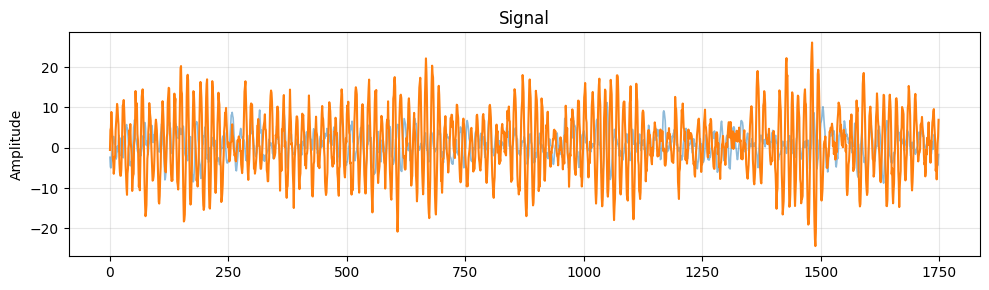

In [12]:
import numpy as np

x = np.load("data/processed/uored_long_test/setup_3/train/N_1_0_102.npy")
y = np.load("data/processed/uored_long_test/setup_3/test/N_5_0_6.npy")[:1750]
z = np.load("data/processed/uored_long_test/setup_3/train/B_11_1_68.npy")

plot_signal(x, y)

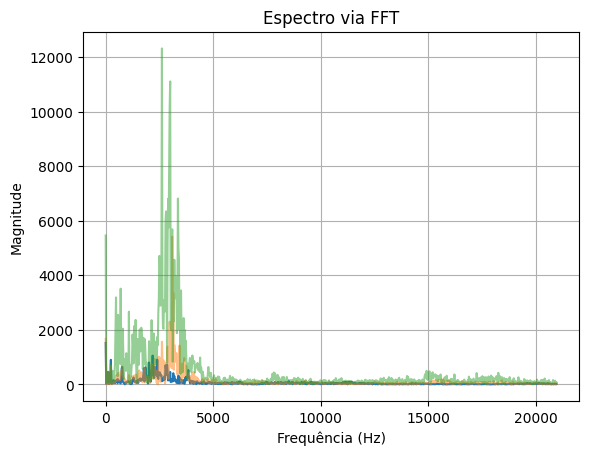

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Exemplo: sinal qualquer
fs = 42000  # frequência de amostragem (Hz), ajuste para o seu caso
t = np.arange(1750) / fs

# FFT
X = np.fft.fft(x)
freqs = np.fft.fftfreq(len(x), d=1/fs)

# FFT
Y = np.fft.fft(y)
freqs = np.fft.fftfreq(len(y), d=1/fs)

Z = np.fft.fft(z)
freqs = np.fft.fftfreq(len(z), d=1/fs)

# Apenas metade positiva do espectro
half = len(x) // 2
plt.plot(freqs[:half], np.abs(X[:half]))
plt.plot(freqs[:half], np.abs(Y[:half]), alpha=0.5)
plt.plot(freqs[:half], np.abs(Z[:half]), alpha=0.5)
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.title("Espectro via FFT")
plt.grid(True)
plt.show()
